In [1]:
# Imports
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from skimage.feature import hog, local_binary_pattern
from sklearn.metrics import roc_curve, auc

In [2]:
# Feature Extraction Function
def extract_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (170, 170))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Color histogram
    color_features = cv2.calcHist(
        [img], [0,1,2], None, [8,8,8], [0,256,0,256,0,256]
    ).flatten()
    
    # Texture (LBP)
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp, bins=np.arange(0, 10), range=(0, 9))
    
    # Shape (HOG)
    hog_features = hog(
        gray,
        orientations=8,
        pixels_per_cell=(16,16),
        cells_per_block=(1,1),
        visualize=False
    )
    return np.hstack([color_features, lbp_hist, hog_features])

In [3]:
# Data Loader Function
def load_dataset(split_dir):
    X, y, filenames = [], [], []
    class_names = sorted([
        d for d in os.listdir(split_dir)
        if os.path.isdir(os.path.join(split_dir, d))
    ])
    class_to_idx = {cls: i for i, cls in enumerate(class_names)}
    
    for cls in class_names:
        cls_path = os.path.join(split_dir, cls)
        for fname in os.listdir(cls_path):
            if not fname.lower().endswith(('.bmp', '.png', '.jpg', '.jpeg')):
                continue
            full_path = os.path.join(cls_path, fname)
            feats = extract_features(full_path)
            X.append(feats)
            y.append(class_to_idx[cls])
            filenames.append(fname)
    
    X = np.vstack(X)
    y = np.array(y)

    # Generates column names based on feature extraction
    color_hist_bins = 8 * 8 * 8  # 512 bins
    lbp_bins = 9  # From bins=np.arange(0, 10)
    hog_features_len = X.shape[1] - color_hist_bins - lbp_bins

    feature_columns = (
        [f'color_hist_{i}' for i in range(color_hist_bins)] +
        [f'lbp_hist_{i}' for i in range(lbp_bins)] +
        [f'hog_feat_{i}' for i in range(hog_features_len)]
    )

    # Wrap NumPy arrays into pandas objects before returning
    X_df = pd.DataFrame(X, columns=feature_columns)
    y_df = pd.Series(y, name='target')

    return X_df, y_df

In [4]:
# Directory Setup
DATA_FOLDER = "./data"
OUTPUT_DIR = "./results"
class_names = ["Abnormal Sperm", "Non Sperm", "Normal Sperm"]
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
# Load Data
X,y = load_dataset(DATA_FOLDER)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=10)

In [6]:
X.head()

,color_hist_0,color_hist_1,color_hist_2,color_hist_3,color_hist_4,color_hist_5,color_hist_6,color_hist_7,color_hist_8,color_hist_9,...,hog_feat_790,hog_feat_791,hog_feat_792,hog_feat_793,hog_feat_794,hog_feat_795,hog_feat_796,hog_feat_797,hog_feat_798,hog_feat_799
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.375466,0.114780,0.379843,0.379843,0.379843,0.379843,0.379843,0.365562,0.379843,0.026061
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.355825,0.355825,0.435240,0.167938,0.435240,0.000000,0.435240,0.435240,0.435240,0.156933
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.384866,0.269465,0.380722,0.380722,0.380722,0.267493,0.380722,0.380722,0.380722,0.242387
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.279784,0.391324,0.411637,0.335697,0.411637,0.174257,0.411637,0.411637,0.411637,0.098565
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.435430,0.000000,0.409403,0.398042,0.409403,0.036056,0.409403,0.409403,0.409403,0.047011


In [7]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [8]:
print(X_train.shape)

(2400, 1321)


In [9]:
print(X_test.shape)

(600, 1321)


In [10]:
# Model Pipelines
# SVM Pipeline
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=10, gamma='scale', probability=True)
)

# Random Forest Pipeline
rf_model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
)

In [11]:
# Train Models
svm_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2


In [12]:
# Evaluation Function
def evaluate_model(model, X, y, class_names, split_name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)

    print(f"\n--- {split_name} Classification Report ---")
    print(classification_report(y, y_pred, target_names=class_names))

    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{split_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(os.path.join(OUTPUT_DIR, f'{split_name.replace(" ", "_")}_confusion.png'))
    plt.show()

    return y_pred, y_prob


--- SVM Test Classification Report ---
                precision    recall  f1-score   support

Abnormal Sperm       0.75      0.76      0.76       201
     Non Sperm       0.92      0.87      0.89       195
  Normal Sperm       0.78      0.81      0.80       204

      accuracy                           0.81       600
     macro avg       0.82      0.82      0.82       600
  weighted avg       0.82      0.81      0.82       600



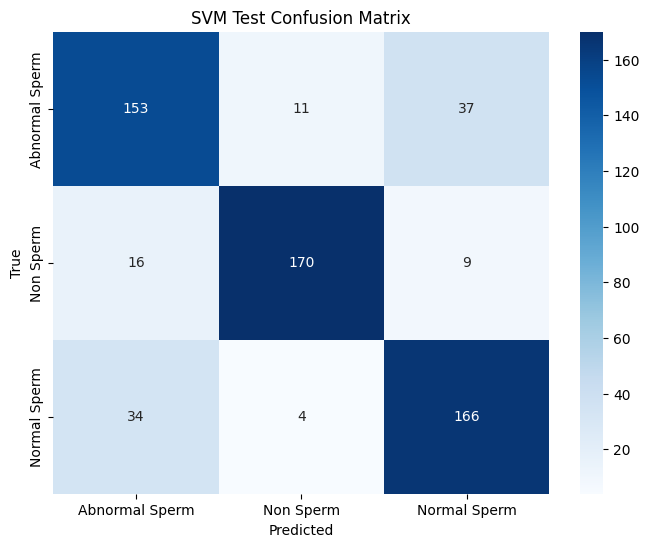


--- RF Test Classification Report ---
                precision    recall  f1-score   support

Abnormal Sperm       0.81      0.78      0.79       201
     Non Sperm       0.90      0.83      0.86       195
  Normal Sperm       0.75      0.84      0.79       204

      accuracy                           0.81       600
     macro avg       0.82      0.81      0.81       600
  weighted avg       0.82      0.81      0.81       600



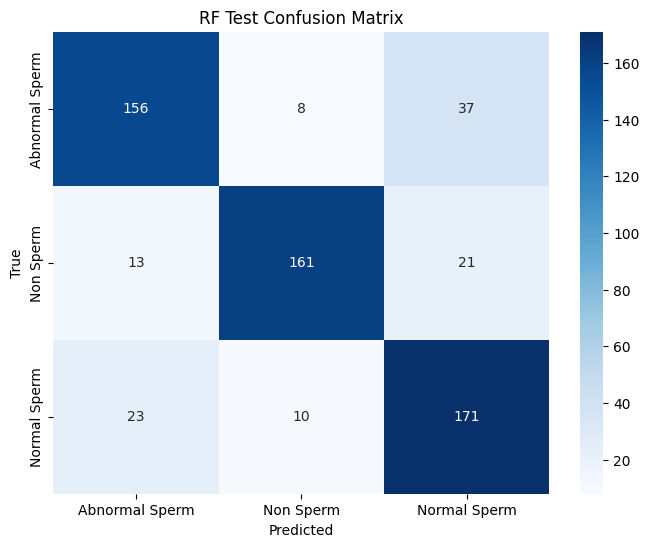

In [13]:
# Evaluate Models
svm_pred, svm_prob = evaluate_model(svm_model, X_test, y_test, class_names, 'SVM Test')
rf_pred, rf_prob = evaluate_model(rf_model, X_test, y_test, class_names, 'RF Test')

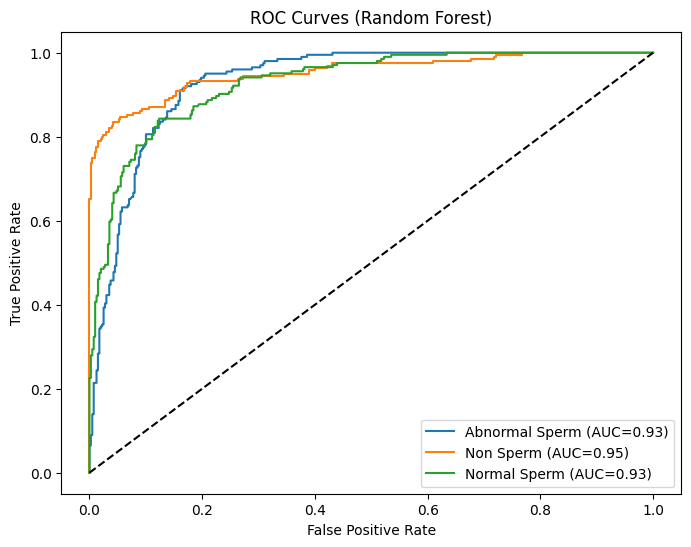

In [14]:
# ROC Curve (Random Forest)
y_bin = label_binarize(y_test, classes=range(len(class_names)))
plt.figure(figsize=(8,6))

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:,i], rf_prob[:,i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves (Random Forest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, 'RF_ROC.png'))
plt.show()

In [15]:
# Prediction Function
def predict_image(image_path, model, class_names):
    # Load & display
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Input: {os.path.basename(image_path)}")
    plt.show()

    # Extract features
    feats = extract_features(image_path).reshape(1, -1)

    # Predict
    pred = model.predict(feats)[0]
    prob = model.predict_proba(feats)[0]

    print(f"Predicted class: {class_names[pred]}")
    for cls, p in zip(class_names, prob):
        print(f"  {cls}: {p:.3f}")
    
    return pred, prob

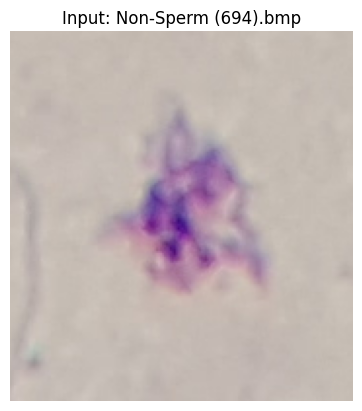

Predicted class: Non Sperm
  Abnormal Sperm: 0.034
  Non Sperm: 0.926
  Normal Sperm: 0.040


C:\Users\aadit\Desktop\Machine Learning\project\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\aadit\Desktop\Machine Learning\project\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


(np.int64(1), array([0.03361986, 0.92607656, 0.04030358]))

In [16]:
# Block 12: Example Usage
sample_image = "./data/Non-Sperm/Non-Sperm (694).bmp"
predict_image(sample_image, rf_model, class_names)